# IoU results

In [1]:
# Automatically reload libraries which change
%load_ext autoreload
%autoreload 2

import json
from pathlib import Path,PureWindowsPath
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from tqdm import tqdm
from IPython.display import display, Markdown
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Markdown, display_markdown # to display images
import random
import math

In [4]:
def find_largest_iou(subresult_list):
    network_iou_list = []
    random_iou_list = []
    
    for subresult in subresult_list:
        network_iou_list.append(subresult["iou_network"])
        random_iou_list.append(subresult["random_baseline_iou"])
    
    return np.array(network_iou_list).max(), np.array(random_iou_list).max()
    

In [12]:
result_file = Path("../result_dec_overfit_train.json")

In [13]:
with open(result_file, "r") as fp:
    data = json.load(fp)  

In [8]:
data[0]

{'sequence_index': 0,
 'central_body_id': 'cf962214-059a-11ec-9f7a-02631ee0d5cb',
 'matching_neighbouring_bodies_k': [],
 'assembly_id': '79682_b75071d6',
 'assembly_num_bodies': 2,
 'assembly_num_contacts': 1}

In [5]:
def find_mean_ious(data, k, assembly_filter):
    ious_from_search = []
    ious_random = []
    ious_random_neighbors = []
    for seq in data:
        for tk in seq["top_k_ious"]:
            if tk["k"] == k:
                ious_from_search_for_seq = []
                ious_random_for_seq = []
                ious_random_neighbors_for_seq = []
                for assembly_info in tk["assembly_info"]:
                    if assembly_filter(assembly_info):                    
                        ious_from_search_for_seq.append(assembly_info["iou_from_search"])
                        ious_random_for_seq.append(assembly_info["iou_random"])
                        ious_random_neighbors_for_seq.append(assembly_info["iou_random_neighbors"])
                # Here we take the top k result
                if len(ious_from_search_for_seq) > 0:
                    ious_from_search.append(np.array(ious_from_search_for_seq).max())
                    assert len(ious_random_for_seq) > 0, "Should have random baselines"
                    assert len(ious_random_neighbors_for_seq) > 0, "Should have random baselines"
                if len(ious_random_for_seq) > 0:
                    ious_random.append(np.array(ious_random_for_seq).max())
                if len(ious_random_neighbors_for_seq) > 0:
                    ious_random_neighbors.append(np.array(ious_random_neighbors_for_seq).max())
                
    #print(ious_from_search)
    mean_iou_from_search = np.array(ious_from_search).mean()
    mean_iou_random = np.array(ious_random).mean()
    mean_iou_random_neighbors = np.array(ious_random_neighbors).mean()
    return mean_iou_from_search, mean_iou_random, mean_iou_random_neighbors
                

In [6]:
def print_results(data, assembly_filter):
    k_values = [1, 5, 10]
    print(f"         iou_from_search  iou_random     iou_random_neighbors")
    for k in k_values:
        iou_from_search, iou_random, iou_random_neighbors = find_mean_ious(data, k, assembly_filter)
        print(f"k = {k:2d}   {100*iou_from_search:.2f}%                 {100*iou_random:.2f}%                  {100*iou_random_neighbors:.2f}%")


In [ ]:
def bigger_than_x(assembly_info):
    return assembly_info["assembly_num_bodies"] > 20
    #return assembly_info["dist"] < 0.1
 
print_results(data, bigger_than_x)

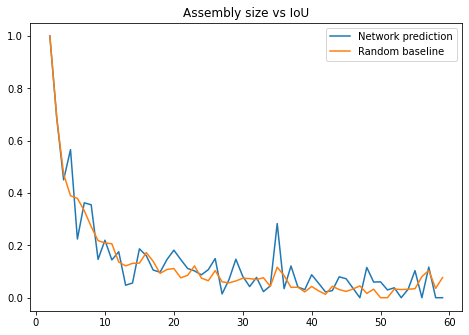

In [7]:
assembly_size = []
ious = []
random_baseline = []
window = 4
for n in range(2, 60):
    def assembly_size_bigger_than(assembly_info):
        return assembly_info["assembly_num_bodies"] == n
    iou_from_search, iou_random, iou_random_neighbors = find_mean_ious(data, 1, assembly_size_bigger_than)
    ious.append(iou_from_search)
    random_baseline.append(iou_random)
    assembly_size.append(n)

fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.plot(assembly_size, ious, label="Network prediction")
ax.plot(assembly_size, random_baseline, label="Random baseline")
ax.legend()
plt.title("Assembly size vs IoU")
plt.show()
plt.close()

In [12]:
def find_mean_ious_test_set(data, seq_filter, n):
    ious_network = []
    ious_random_neighbors = []
    for seq in data:
        if seq_filter(seq, n):
            if len(seq["matching_neighbouring_bodies_k"]) > 0:
                iou_network_largest, iou_random_largest = find_largest_iou(seq["matching_neighbouring_bodies_k"])
                #ious_network.append(seq["iou_network"])
                ious_network.append(iou_network_largest)
                #ious_random_neighbors.append(seq["random_baseline_iou"])
                ious_random_neighbors.append(iou_random_largest)
                
    #print(ious_from_search)
    print(len(ious_network))
    mean_iou_from_network = np.array(ious_network).mean()
    mean_iou_random_neighbors = np.array(ious_random_neighbors).mean()
    return mean_iou_from_network, mean_iou_random_neighbors

def print_ious(data, seq_filter, k, n):
    mean_iou_from_network, mean_iou_random_neighbors = find_mean_ious_test_set(data, seq_filter, n)
    print(f"k={k}, n>{n}:      IoU_network = {100*mean_iou_from_network:.2f}%    IoU_random_neighbors = {100*mean_iou_random_neighbors:.2f}%")

In [13]:
def assembly_size(seq, n):
    return seq["assembly_num_bodies"] > n

ks = [1]
ns = [1, 10, 20, 30, 40, 50]
for k in ks:
    test_set_result_file = Path(f"../model_outputs/result_retrieve_1.json")
    with open(test_set_result_file, "r") as fp:
        test_set_results = json.load(fp)
    
    for n in ns:
        print_ious(test_set_results, assembly_size, k, n)

1111
k=1, n>1:      IoU_network = 58.49%    IoU_random_neighbors = 15.54%
863
k=1, n>10:      IoU_network = 53.97%    IoU_random_neighbors = 9.39%
553
k=1, n>20:      IoU_network = 53.23%    IoU_random_neighbors = 6.44%
416
k=1, n>30:      IoU_network = 50.84%    IoU_random_neighbors = 5.43%
218
k=1, n>40:      IoU_network = 41.70%    IoU_random_neighbors = 3.88%
103
k=1, n>50:      IoU_network = 38.74%    IoU_random_neighbors = 2.48%


/tmp/ipykernel_3380/3654374108.py:14: RuntimeWarning: Mean of empty slice.
  mean_iou_from_network = np.array(ious_network).mean()
/tmp/ipykernel_3380/3654374108.py:15: RuntimeWarning: Mean of empty slice.
  mean_iou_random_neighbors = np.array(ious_random_neighbors).mean()


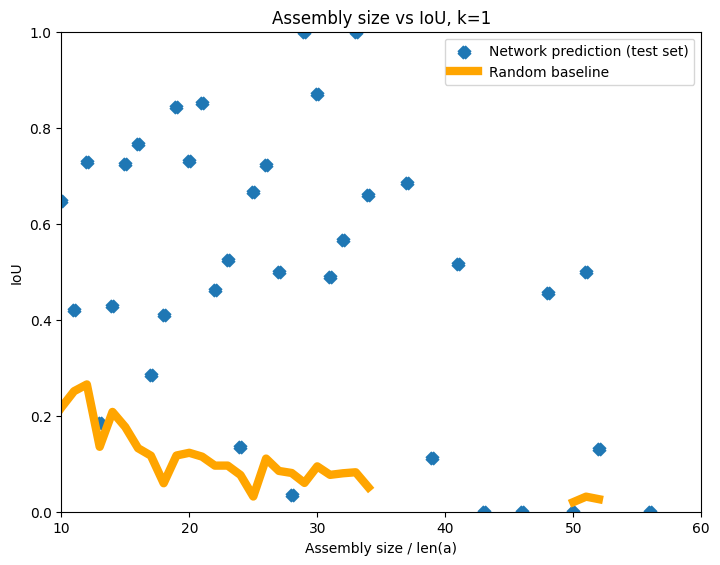

In [11]:
for k in ks:
    test_set_result_file = Path(f"../model_outputs/result_retrieve_1.json")
    with open(test_set_result_file, "r") as fp:
        test_set_results = json.load(fp)

    test_set_assembly_size = []
    test_set_ious = []
    test_set_random_baseline = []
    for n in range(2, 60):
        def assembly_size_bigger_than(seq, n):
            return seq["assembly_num_bodies"] == n
        mean_iou_from_network, mean_iou_random_neighbors = find_mean_ious_test_set(test_set_results, assembly_size_bigger_than, n)
        test_set_ious.append(mean_iou_from_network)
        test_set_random_baseline.append(mean_iou_random_neighbors)
        test_set_assembly_size.append(n)

    fig = plt.figure()
    ax = fig.add_axes([0,0,1,1])
    ax.scatter(test_set_assembly_size, test_set_ious, marker='x', linewidth=6, label="Network prediction (test set)")
    ax.plot(test_set_assembly_size, test_set_random_baseline, color='orange', linewidth=6, label="Random baseline")
    ax.legend()
    plt.title(f"Assembly size vs IoU, k={k}")
    plt.xlim([10, 60])
    plt.ylim([0, 1.0])
    plt.xlabel('Assembly size / len(a)')
    plt.ylabel('IoU')
    plt.show()
    plt.close()